In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import image_dataset_from_directory

In [28]:
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [29]:
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/Third semester/Exams/CNN_men_women'

BATCH_SIZE = 32
IMG_SHAPE = 150
EPOCHS = 10
LEARNING_RATE = 0.0001

In [30]:
train_ds = image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SHAPE, IMG_SHAPE),
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SHAPE, IMG_SHAPE),
    batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [31]:
base_model = MobileNetV2(input_shape=(IMG_SHAPE, IMG_SHAPE, 3),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False

model = Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SHAPE, IMG_SHAPE, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/tmp/ipython-input-169478091.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMG_SHAPE, IMG_SHAPE, 3),
/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6154 - loss: 0.6811 - val_accuracy: 0.7200 - val_loss: 0.5612
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6496 - loss: 0.6110 - val_accuracy: 0.7550 - val_loss: 0.5243
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7187 - loss: 0.5670 - val_accuracy: 0.7950 - val_loss: 0.4912
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7308 - loss: 0.5520 - val_accuracy: 0.8000 - val_loss: 0.4742
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7550 - loss: 0.5357 - val_accuracy: 0.8100 - val_loss: 0.4564
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7464 - loss: 0.5114 - val_accuracy: 0.8200 - val_loss: 0.4396
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7488 - loss: 0.5042 - val_accuracy: 0.8200 - val_loss: 0.4283
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7769 - loss: 0.4845 - val_accuracy: 0.8150 - va

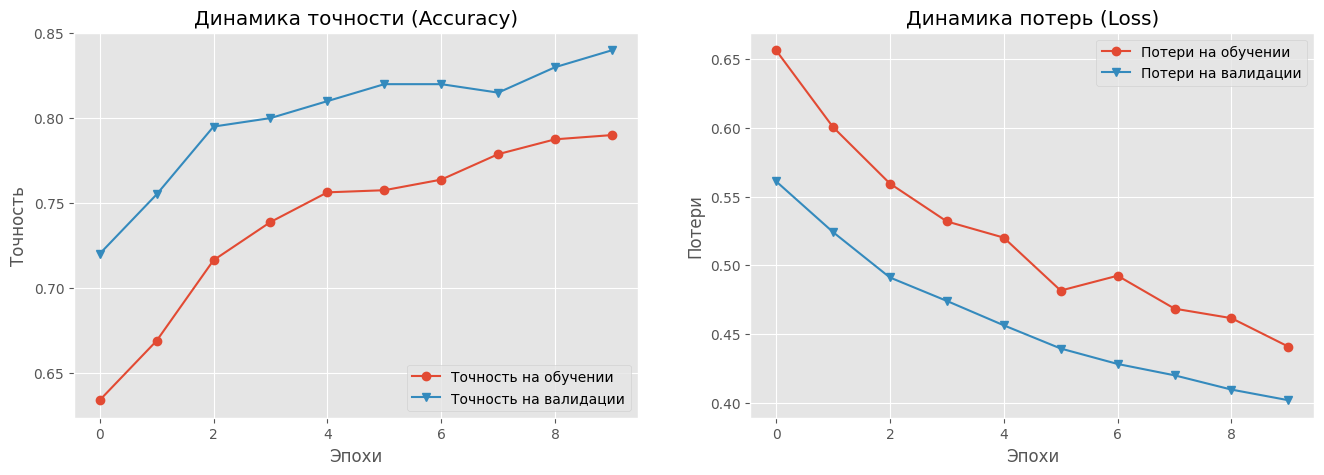

In [33]:
plt.style.use('ggplot')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точность на обучении', marker='o')
plt.plot(epochs_range, val_acc, label='Точность на валидации', marker='v')
plt.legend(loc='lower right')
plt.title('Динамика точности (Accuracy)')
plt.xlabel('Эпохи')
plt.ylabel('Точность')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Потери на обучении', marker='o')
plt.plot(epochs_range, val_loss, label='Потери на валидации', marker='v')
plt.legend(loc='upper right')
plt.title('Динамика потерь (Loss)')
plt.xlabel('Эпохи')
plt.ylabel('Потери')

plt.show()

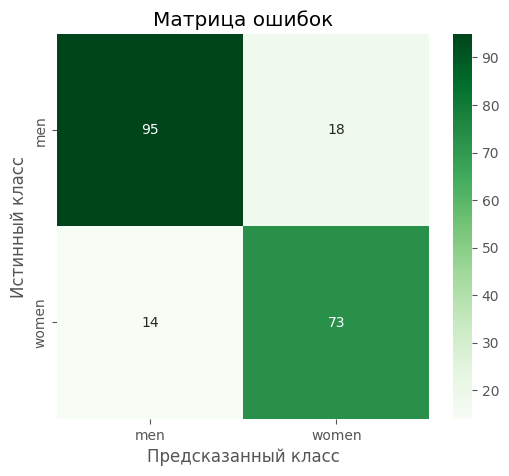

              precision    recall  f1-score   support

         men       0.87      0.84      0.86       113
       women       0.80      0.84      0.82        87

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



In [34]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype("int32").flatten())

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.title('Матрица ошибок')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))